In [137]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os
from datetime import datetime
import tensorflow_probability as tfp
tfd = tfp.distributions

class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self, PROGRESS_EPOCH=50):
        self.PROGRESS_EPOCH = PROGRESS_EPOCH
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.PROGRESS_EPOCH == 0:
            print(f"{datetime.now().strftime("%H:%M:%S")}, epoch {epoch}: ", end="")
            for key, val in logs.items():
                print(f"{key}: {val:.3f}", end= "\t")
            print()

tf.config.list_physical_devices('GPU')

SyntaxError: f-string: unmatched '(' (1313476622.py, line 15)

# importing data

In [2]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [3]:
out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [4]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")

In [5]:
non_nan_range = np.arange(24, 46)
all_curves = np.array([])
k_set = None
for fil in sim_names:
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    nan_sum = sum(sum(np.isnan(np.array(list(curves.values()))))[non_nan_range])
    assert (nan_sum == 0), fil
    assert (sum(np.isnan(np.array(list(curves.values()))))[23] == 34)
    assert (sum(np.isnan(np.array(list(curves.values()))))[46] == 34)
    if k_set is None:
        k_set = ks[0]
    for k in ks.values():
        assert((k == k_set).all()), print(fil, k, k_set)

In [6]:
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [7]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves)), np.sum(np.isnan(all_cosmologies)))

(999, 34, 22) (999, 6)
0 0


In [8]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)


In [9]:
train_split

849

In [91]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaler.fit(train_y)
# train_y_sc = scaler.transform(train_y)
# val_y_sc = scaler.transform(val_y)

# BNN

In [127]:
kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /  # pylint: disable=g-long-lambda
                           tf.cast(train_split, dtype=tf.float32))

In [158]:
input_shape = (34, 22, 1) 

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=input_shape),
    tfp.layers.Convolution2DFlipout(filters = 4, kernel_size=(2, 2), padding='valid',
          kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
    tfp.layers.Convolution2DFlipout(filters = 16, kernel_size=(2, 2), padding='valid',
          kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
    tfp.layers.Convolution2DFlipout(filters = 16, kernel_size=(2, 2), padding='valid',
          kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
    tf.keras.layers.Flatten(),
    tfp.layers.DenseFlipout(units = 128,
          kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh),
    tfp.layers.DenseFlipout(units = 64,
          kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh),
    tf.keras.layers.Dense(tfp.layers.MultivariateNormalTriL.params_size(6)),
    tfp.layers.MultivariateNormalTriL(6)
])

In [99]:
# input_shape = (34, 22, 1) 

# tf.keras.backend.clear_session()

# model = tf.keras.Sequential([
#     tf.keras.layers.InputLayer(input_shape=input_shape),
#     tf.keras.layers.BatchNormalization(),
#     tfp.layers.Convolution2DFlipout(filters = 8, kernel_size=(2, 2), padding='valid',
#           kernel_divergence_fn=kl_divergence_function, activation=tf.nn.relu),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
#     tf.keras.layers.BatchNormalization(),
#     tfp.layers.Convolution2DFlipout(filters = 16, kernel_size=(2, 2), padding='valid',
#           kernel_divergence_fn=kl_divergence_function, activation=tf.nn.relu),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
#     tf.keras.layers.BatchNormalization(),
#     tfp.layers.Convolution2DFlipout(filters = 16, kernel_size=(2, 2), padding='valid',
#           kernel_divergence_fn=kl_divergence_function, activation=tf.nn.relu),
#     tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Flatten(),
#     tfp.layers.DenseFlipout(units = 128,
#           kernel_divergence_fn=kl_divergence_function, activation=tf.nn.leaky_relu),
#     tf.keras.layers.BatchNormalization(),
#     tfp.layers.DenseFlipout(units = 64,
#           kernel_divergence_fn=kl_divergence_function, activation=tf.nn.relu),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dense(tfp.layers.MultivariateNormalTriL.params_size(6)),
#     tfp.layers.MultivariateNormalTriL(6)
# ])

In [159]:
# Define loss
# temp_ytrue, temp_ypred = None, None
def negloglik(y_true, y_pred):
    # global temp_ytrue, temp_ypred
    # temp_ytrue, temp_ypred = y_true, y_pred
    return -tf.reduce_mean(y_pred.log_prob(y_true))

# Define the optimizer 
optimizer=tf.keras.optimizers.Adadelta(learning_rate=0.2, rho=0.98)
# optimizer=tf.keras.optimizers.Adadelta()

model.compile(optimizer, loss=negloglik, # tf.keras.losses.LogCosh(), # ['mse'], 
              metrics=['mae', 'mse'], experimental_run_tf_function=False)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_flipout (Conv2DFlipo  (None, 33, 21, 8)        72        
 ut)                                                             
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 10, 8)        0         
 )                                                               
                                                                 
 conv2d_flipout_1 (Conv2DFli  (None, 15, 9, 16)        1040      
 pout)                                                           
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 4, 16)         0         
 2D)                                                             
                                                                 
 conv2d_flipout_2 (Conv2DFli  (None, 6, 3, 16)         2

In [133]:
history = model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y), verbose=0, callbacks=[CustomCallback(1)])


KeyboardInterrupt



In [160]:
history = model.fit(train_x, train_y, epochs=1000, validation_data=(val_x, val_y), verbose=0, callbacks=[CustomCallback(100)])

epoch 0: loss: 57.056	mae: 1.134	mse: 2.123	val_loss: 54.722	val_mae: 1.040	val_mse: 1.833	
epoch 100: loss: 44.782	mae: 0.584	mse: 0.825	val_loss: 44.909	val_mae: 0.630	val_mse: 0.881	
epoch 200: loss: 36.637	mae: 0.586	mse: 0.838	val_loss: 36.328	val_mae: 0.626	val_mse: 0.948	
epoch 300: loss: 31.092	mae: 0.582	mse: 0.842	val_loss: 30.999	val_mae: 0.561	val_mse: 0.726	
epoch 400: loss: 27.672	mae: 0.591	mse: 0.859	val_loss: 27.528	val_mae: 0.579	val_mse: 0.792	
epoch 500: loss: 25.342	mae: 0.589	mse: 0.838	val_loss: 25.413	val_mae: 0.600	val_mse: 0.843	
epoch 600: loss: 23.535	mae: 0.579	mse: 0.819	val_loss: 23.801	val_mae: 0.558	val_mse: 0.743	
epoch 700: loss: 22.038	mae: 0.583	mse: 0.839	val_loss: 22.038	val_mae: 0.561	val_mse: 0.754	
epoch 800: loss: 20.822	mae: 0.578	mse: 0.810	val_loss: 20.856	val_mae: 0.551	val_mse: 0.718	
epoch 900: loss: 19.634	mae: 0.570	mse: 0.812	val_loss: 19.799	val_mae: 0.555	val_mse: 0.738	


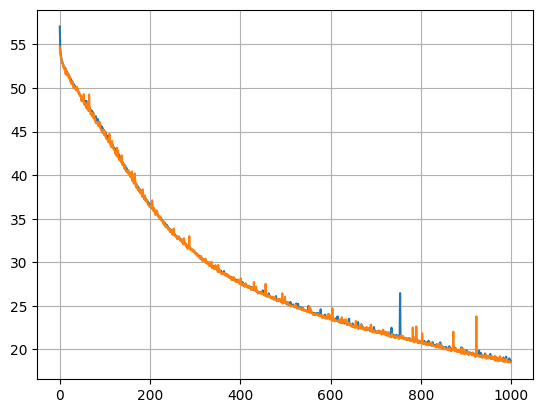

In [161]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
# plt.loglog()
plt.grid()
plt.show()
plt.close()

In [109]:
model.predict(train_x[0:1], callbacks=[CustomCallback()]), train_y[0:1]#, train_y_sc[0:1]

Start predicting; got log keys: []
...Predicting: start of batch 0; got log keys: []
...Predicting: end of batch 0; got log keys: ['outputs']
1/1 [==============================] - 0s 23ms/step


(array([[ 0.5136899 ,  0.75270104, -0.26575232,  2.469296  ,  1.2209787 ,
          0.9171307 ]], dtype=float32),
 array([[0.309  , 0.979  , 3.11234, 1.12194, 0.6685 , 0.53182]]))

In [162]:
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

2/2 [==============================] - 0s 8ms/step - loss: 18.6035 - mae: 0.5965 - mse: 0.9340
Test loss: [18.60352325439453, 0.5965369939804077, 0.9339550733566284]


4/4 [==============================] - 1s 5ms/step


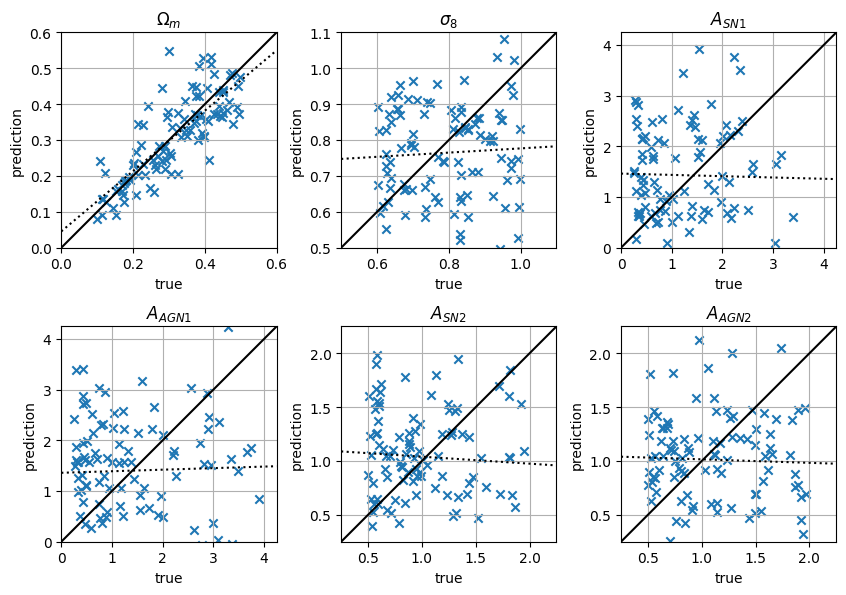

In [163]:
# plot_x, plot_y = train_x, train_y
plot_x, plot_y = val_x, val_y
# plot_x, plot_y = test_x, test_y

predictions = model.predict(plot_x)
upp_lims = [0.6, 1.1,4.25,4.25,2.25, 2.25]
low_lims = [0, 0.5, 0, 0, 0.25, 0.25]
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(plot_y[:, ind], predictions[:, ind], 1))
    ax.scatter(plot_y[:, ind], predictions[:, ind], marker="x")
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    ax.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    ax.set_xlim([low_lim, upp_lim])
    ax.set_ylim([low_lim, upp_lim])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(label)
    ax.grid()
plt.show()
plt.close()

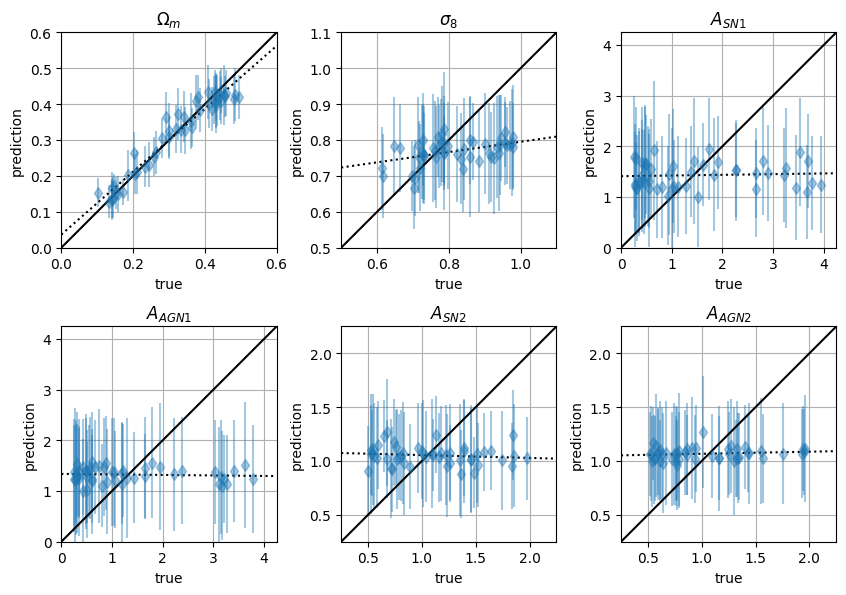

In [164]:
# plot_x, plot_y = train_x, train_y
# plot_x, plot_y = val_x, val_y
plot_x, plot_y = test_x, test_y

n_pred = 50
predictions = np.empty((n_pred, *plot_y.shape))
for i in range(n_pred):
    predictions[i] = model.predict(plot_x, verbose=0)
predictions_best = np.nanmean(predictions, axis=0)
predictions_std = np.nanstd(predictions, axis=0)

upp_lims = [0.6, 1.1,4.25,4.25,2.25, 2.25]
low_lims = [0, 0.5, 0, 0, 0.25, 0.25]
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(plot_y[:, ind], predictions_best[:, ind], 1))
    ax.errorbar(plot_y[:, ind], predictions_best[:, ind],  predictions_std[:, ind], marker="d", ls='none', alpha=0.4)
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    ax.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    ax.set_xlim([low_lim, upp_lim])
    ax.set_ylim([low_lim, upp_lim])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(label)
    ax.grid()
plt.show()
plt.close()

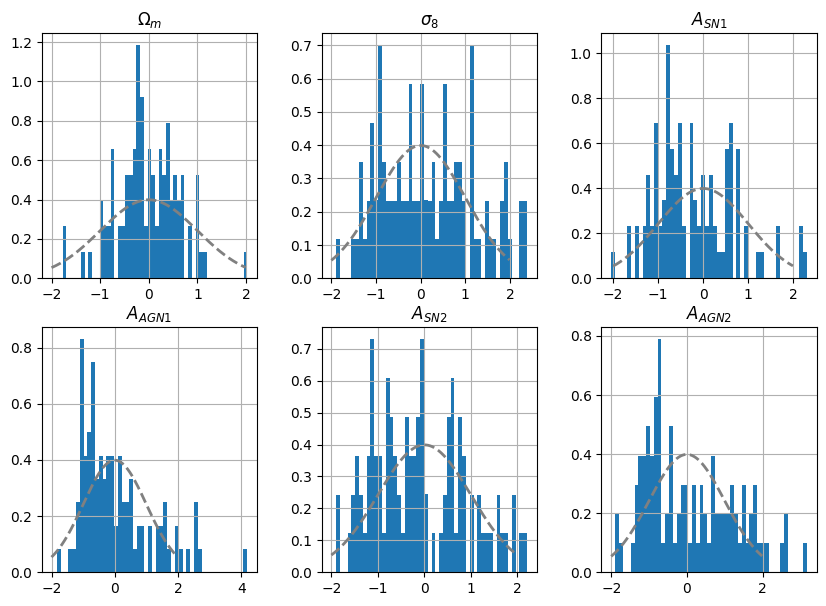

In [172]:
# plot_x, plot_y = train_x, train_y
plot_x, plot_y = val_x, val_y
# plot_x, plot_y = test_x, test_y

n_pred = 20
predictions = np.empty((n_pred, *plot_y.shape))
for i in range(n_pred):
    predictions[i] = model.predict(plot_x, verbose=0)
predictions_best = np.nanmean(predictions, axis=0)
predictions_std = np.nanstd(predictions, axis=0)

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    ax.hist((plot_y[:, ind] - predictions_best[:, ind]) / predictions_std[:, ind], bins = 50, density=True)
    ax.plot(np.arange(-2, 2, 0.01), 1./(np.sqrt(2*np.pi))*np.exp(-(np.arange(-2, 2, 0.01)**2)/2.),linestyle = "--",linewidth = 2,color="grey")
    ax.set_title(label)
    ax.grid()
plt.show()
plt.close()